# Visualización de datos con Seaborn
### Dataset: Encuesta de hogares Argentina — ingresos, gastos y condiciones socioeconómicas

> **¿Qué es Seaborn y por qué usarlo?**
> Seaborn es una librería de visualización construida sobre Matplotlib. No la reemplaza — la extiende. Mientras Matplotlib es una librería de propósito general que da control total sobre cada elemento del gráfico, Seaborn se especializa en **gráficos estadísticos**: distribuciones, relaciones entre variables y comparaciones entre categorías.
>
> Las ventajas principales de Seaborn son:
> - Está integrado con pandas: acepta DataFrames directamente sin necesidad de extraer columnas.
> - Produce gráficos más elaborados con menos código.
> - Calcula automáticamente estimaciones estadísticas (medias, intervalos de confianza, densidades).
> - Tiene una paleta de colores y estilos por defecto más cuidada visualmente.
>
> Por convención Seaborn se importa como `sns`.

---

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sns.set configura el estilo visual global
# style: aspecto del fondo y la grilla
# context: escala de los elementos (tamaño de texto, líneas)
sns.set(style="whitegrid", context="notebook")

In [ ]:
# Cargar el dataset
df = pd.read_csv('hogares_argentina.csv')
df_viz = df[df['ingreso_mensual'] < df['ingreso_mensual'].quantile(0.97)].copy()

print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 800 filas, 12 columnas


,region,nivel_educativo,tipo_empleo,tipo_vivienda,miembros_hogar,ingreso_mensual,gasto_alimentos,gasto_vivienda,gasto_salud,gasto_educacion,ahorro_mensual,acceso_servicios
0,Pampeana,Terciario,Informal,Casa propia,2,206578,64267,48508,2057,7183.0,80011.0,4.5
1,AMBA,Primario,Formal,Casa propia,4,387882,161228,103773,30527,871.0,79473.0,1.1
2,AMBA,Secundario,Informal,Casa propia,2,154754,59114,62921,5487,13709.0,7046.0,3.2
3,Patagonia,Terciario,Formal,Casa propia,3,382296,122628,83032,18048,23257.0,118640.0,1.9
4,NEA,Secundario,Informal,Alquilada,3,132911,39275,15684,6392,17101.0,NaN,1.9


---

## — Introducción a Seaborn: estilos y contextos

> **Síntesis teórica**
>
> Seaborn ofrece dos configuraciones principales que controlan la apariencia de todos los gráficos:
>
> **Estilos (`style`)** — controlan el fondo y la grilla:
> - `"whitegrid"`: fondo blanco con grilla visible. Ideal para comparar valores.
> - `"darkgrid"`: fondo gris oscuro con grilla clara. Contraste alto.
> - `"white"`: fondo blanco sin grilla. Limpio y minimalista.
> - `"dark"`: fondo gris oscuro sin grilla.
> - `"ticks"`: fondo blanco con marcas en los ejes.
>
> **Contextos (`context`)** — controlan la escala visual (tamaño de texto, líneas, marcadores):
> - `"paper"`: elementos pequeños, para impresión.
> - `"notebook"`: tamaño medio, por defecto para Colab.
> - `"talk"`: elementos más grandes, para presentaciones.
> - `"poster"`: muy grandes, para afiches.
>
> **¿Cuándo cambiar el contexto?** Si el gráfico va a presentarse en pantalla grande o proyectarse, `"talk"` o `"poster"` hacen que los textos y líneas sean más legibles desde lejos.

### 1.1 Comparación de estilos

/tmp/ipykernel_15602/526775519.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ingreso_region.index, rotation=45, fontsize=7)
/tmp/ipykernel_15602/526775519.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ingreso_region.index, rotation=45, fontsize=7)
/tmp/ipykernel_15602/526775519.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ingreso_region.index, rotation=45, fontsize=7)
/tmp/ipykernel_15602/526775519.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ingreso_region.index, rotation=45, fontsize=7)
/tmp/ipykernel_15602/526775519.py:13: UserWarning: set_ticklabel

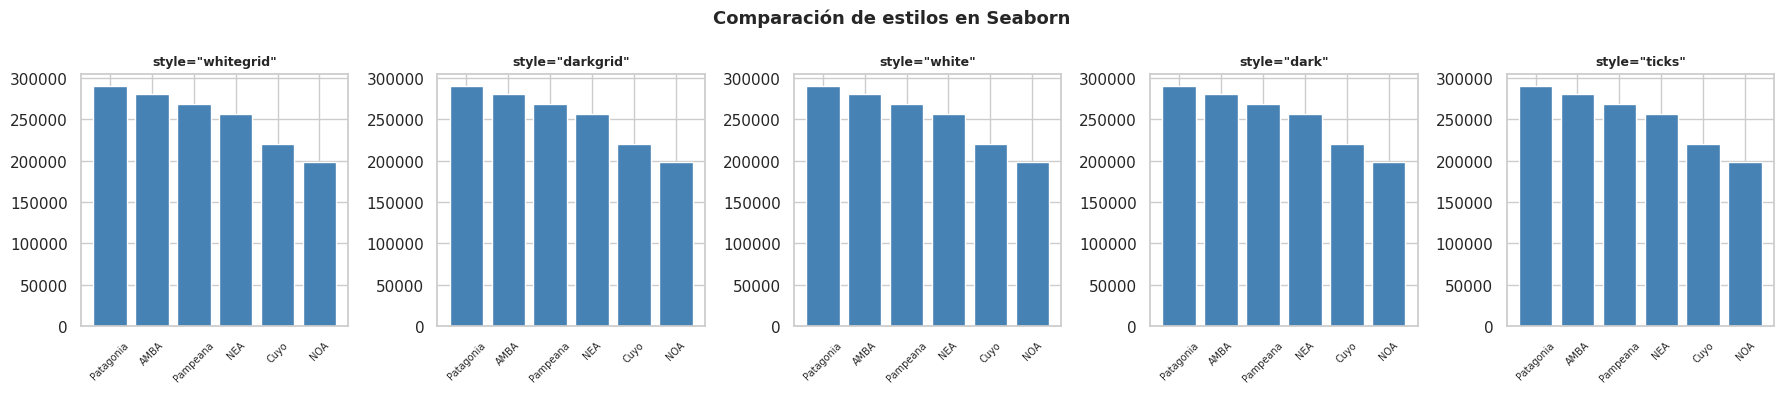

In [ ]:
# Comparar los cinco estilos disponibles sobre el mismo gráfico
estilos = ["whitegrid", "darkgrid", "white", "dark", "ticks"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, estilo in zip(axes, estilos):
    with sns.axes_style(estilo):
        ax_actual = ax
        ingreso_region = (df.groupby('region')['ingreso_mensual']
                          .mean().sort_values(ascending=False))
        ax.bar(ingreso_region.index, ingreso_region.values, color='steelblue')
        ax.set_title(f'style="{estilo}"', fontsize=9, fontweight='bold')
        ax.set_xticklabels(ingreso_region.index, rotation=45, fontsize=7)
        ax.set_ylabel('')

plt.suptitle('Comparación de estilos en Seaborn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** `axes_style()` como context manager aplica el estilo solo dentro del bloque `with`, sin afectar el resto del notebook. `sns.set(style=...)` lo aplica globalmente. Para exploración en notebook, `whitegrid` es el más legible. Para publicaciones, `white` o `ticks` son más limpios.

### 1.2 Comparación de contextos

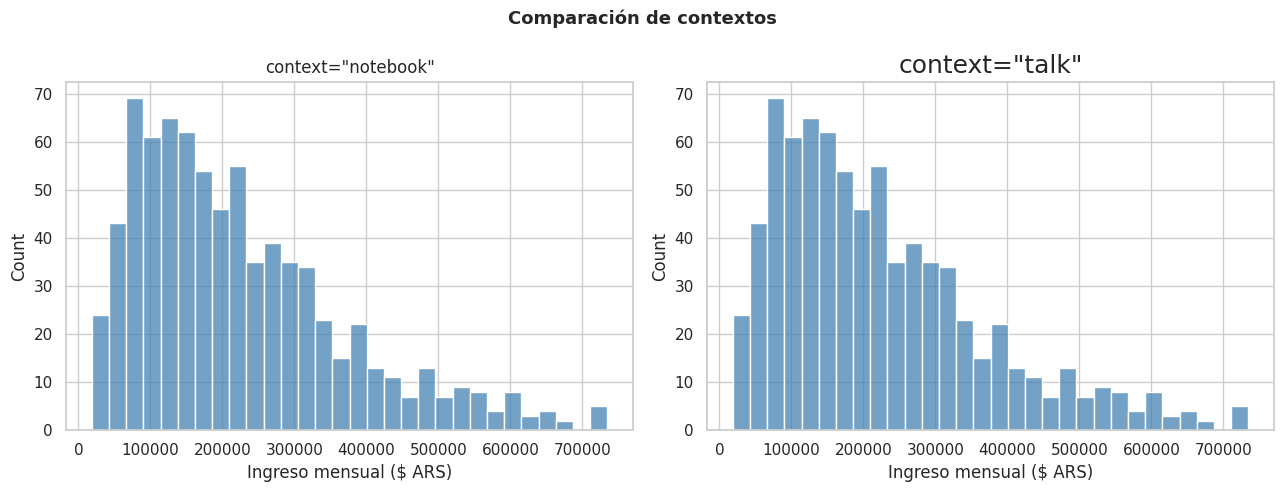

In [ ]:
# Comparar contextos: notebook vs. talk
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, contexto in zip(axes, ["notebook", "talk"]):
    with sns.plotting_context(contexto):
        sns.histplot(data=df_viz, x='ingreso_mensual',
                     bins=30, color='steelblue', ax=ax)
        ax.set_title(f'context="{contexto}"')
        ax.set_xlabel('Ingreso mensual ($ ARS)')

plt.suptitle('Comparación de contextos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** El contexto `talk` escala todos los elementos — texto, líneas, marcadores — para que sean visibles en una presentación. El gráfico es idéntico en datos pero diferente en escala visual. No es necesario cambiar el tamaño de la figura — Seaborn ajusta los elementos internamente.

---

## — Distribuciones: histplot y kdeplot

> **Síntesis teórica**
>
> **`sns.histplot`** — histograma integrado con pandas
> Reemplaza a `plt.hist` con ventajas importantes: acepta DataFrames directamente, calcula múltiples estadísticas en el eje Y (`count`, `density`, `probability`, `percent`), permite superponer la curva KDE con `kde=True`, y controla cómo se muestran múltiples distribuciones con `multiple`.
>
> Parámetro `multiple`:
> - `"layer"`: superpone las distribuciones con transparencia.
> - `"dodge"`: barras una al lado de la otra dentro de cada bin.
> - `"stack"`: barras apiladas.
> - `"fill"`: apiladas y normalizadas a 1.
>
> **`sns.kdeplot`** — curva de densidad suavizada
> Muestra la distribución como una curva continua en lugar de barras. Usa estimación de densidad del kernel (KDE) para suavizar la distribución. Es especialmente útil para comparar distribuciones de forma visual sin que los bins distorsionen la comparación.
>
> **¿Cuándo usar cada uno?**
> - `histplot`: cuando el conteo o la frecuencia importa, o cuando hay pocos datos.
> - `kdeplot`: cuando la forma de la distribución importa más que los conteos exactos.

### 2.1 histplot — comparación matplotlib vs. seaborn

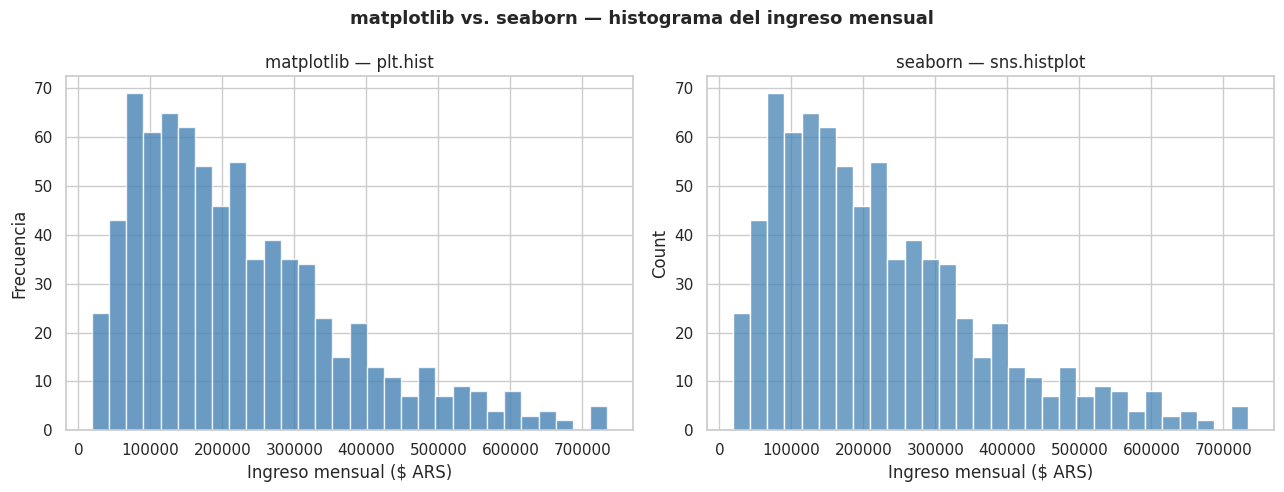

In [ ]:
# Comparación directa: matplotlib vs. seaborn para el mismo histograma
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: matplotlib
axes[0].hist(df_viz['ingreso_mensual'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('matplotlib — plt.hist')
axes[0].set_xlabel('Ingreso mensual ($ ARS)')
axes[0].set_ylabel('Frecuencia')

# Panel derecho: seaborn
# Seaborn acepta el DataFrame directamente con x= como nombre de columna
sns.histplot(data=df_viz, x='ingreso_mensual', bins=30,
             color='steelblue', ax=axes[1])
axes[1].set_title('seaborn — sns.histplot')
axes[1].set_xlabel('Ingreso mensual ($ ARS)')

plt.suptitle('matplotlib vs. seaborn — histograma del ingreso mensual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** El resultado visual es similar, pero el código de Seaborn es más conciso: no es necesario extraer la columna del DataFrame ni configurar el color del borde. Seaborn infiere el label del eje X desde el nombre de la columna automáticamente.

### 2.2 histplot con hue — distribuciones por grupo

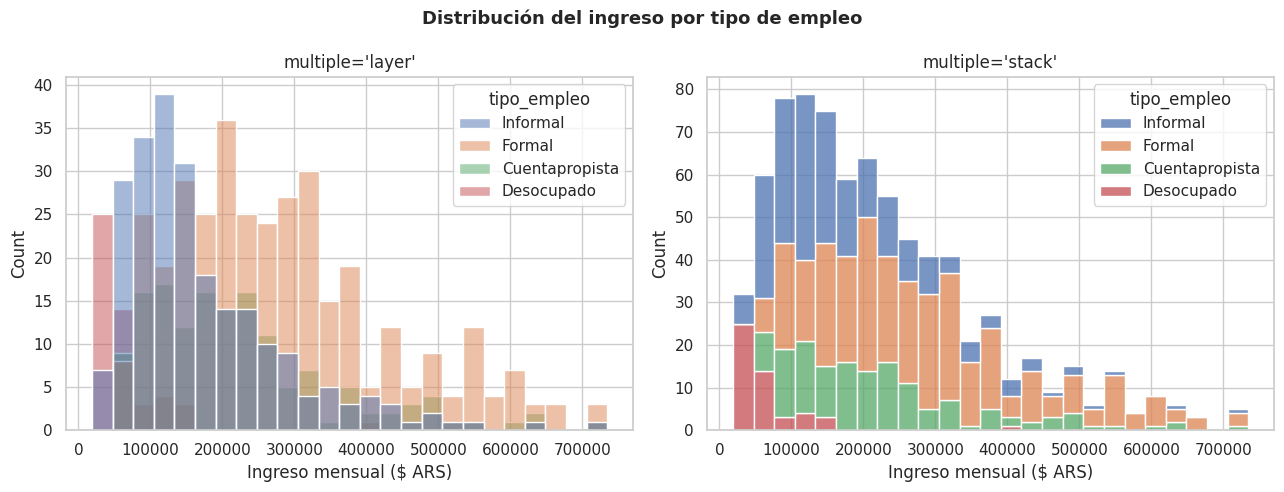

In [ ]:
# hue separa la distribución por una variable categórica
# kde=True agrega la curva de densidad sobre las barras
# multiple='layer' superpone las distribuciones con transparencia

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: multiple='layer' (superposición)
sns.histplot(data=df_viz, x='ingreso_mensual', hue='tipo_empleo',
             bins=25, kde=False, multiple='layer',
             alpha=0.5, ax=axes[0])
axes[0].set_title("multiple='layer'")
axes[0].set_xlabel('Ingreso mensual ($ ARS)')

# Panel derecho: multiple='stack' (apilado)
sns.histplot(data=df_viz, x='ingreso_mensual', hue='tipo_empleo',
             bins=25, kde=False, multiple='stack',
             ax=axes[1])
axes[1].set_title("multiple='stack'")
axes[1].set_xlabel('Ingreso mensual ($ ARS)')

plt.suptitle('Distribución del ingreso por tipo de empleo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** `multiple='layer'` muestra las distribuciones superpuestas — útil para comparar formas. `multiple='stack'` las apila — útil para ver la composición total en cada bin. Con `hue`, Seaborn asigna colores automáticamente y genera la leyenda sin código adicional.

### 2.3 kdeplot — curvas de densidad

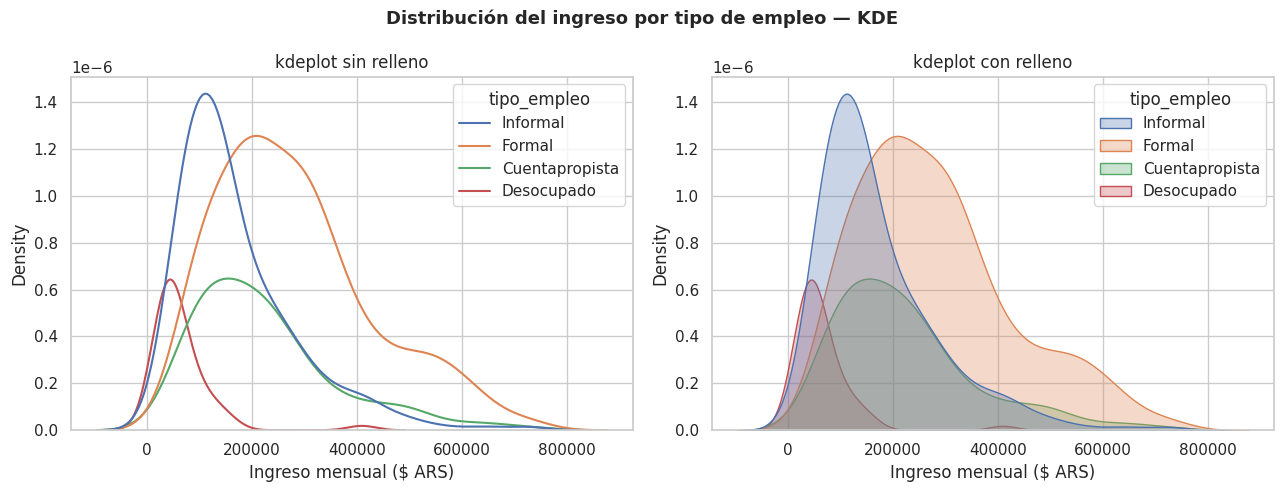

In [ ]:
# kdeplot muestra la distribución como curva continua
# fill=True rellena el área bajo la curva
# alpha controla la transparencia del relleno

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: KDE sin relleno
sns.kdeplot(data=df_viz, x='ingreso_mensual',
            hue='tipo_empleo', ax=axes[0])
axes[0].set_title('kdeplot sin relleno')
axes[0].set_xlabel('Ingreso mensual ($ ARS)')

# Panel derecho: KDE con relleno
sns.kdeplot(data=df_viz, x='ingreso_mensual',
            hue='tipo_empleo', fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('kdeplot con relleno')
axes[1].set_xlabel('Ingreso mensual ($ ARS)')

plt.suptitle('Distribución del ingreso por tipo de empleo — KDE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** La curva KDE suaviza la distribución eliminando el ruido de los bins. Permite ver claramente que Formal (azul) tiene su pico más a la derecha que Informal (rojo), y que Desocupado (verde) está completamente concentrado en valores bajos. El relleno con `fill=True` facilita identificar las zonas de superposición entre distribuciones.

### 2.4 histplot con kde=True

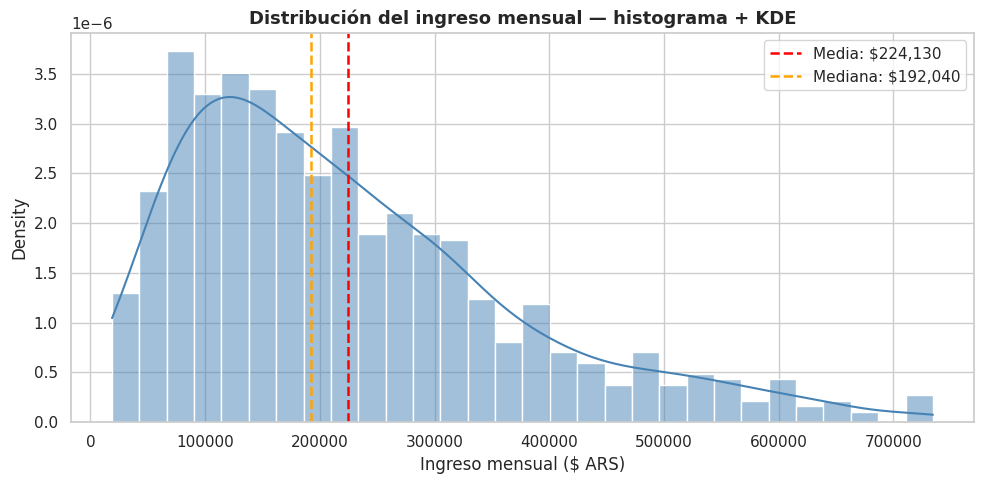

In [ ]:
# Combinar histograma + curva KDE en un solo gráfico
# stat='density' normaliza el eje Y para que sea compatible con la curva KDE

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df_viz, x='ingreso_mensual',
             bins=30, kde=True,
             color='steelblue',
             stat='density')   # density normaliza el área total a 1

# Agregar líneas de referencia con matplotlib (Seaborn usa matplotlib por debajo)
ax.axvline(df_viz['ingreso_mensual'].mean(),
           color='red', linestyle='--', linewidth=1.8,
           label=f'Media: ${df_viz["ingreso_mensual"].mean():,.0f}')
ax.axvline(df_viz['ingreso_mensual'].median(),
           color='orange', linestyle='--', linewidth=1.8,
           label=f'Mediana: ${df_viz["ingreso_mensual"].median():,.0f}')
ax.legend()
ax.set_title('Distribución del ingreso mensual — histograma + KDE',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ingreso mensual ($ ARS)')
plt.tight_layout()
plt.show()

> **Interpretación:** `kde=True` superpone la curva de densidad sobre las barras. `stat='density'` normaliza el eje Y para que sea compatible con la escala de la curva KDE — sin esta opción, la escala de las barras (frecuencia) y la curva (densidad) serían incompatibles. Las líneas de referencia se agregan con Matplotlib porque Seaborn construye sus gráficos sobre `plt.axes()`.

---

## — Relaciones entre variables: scatterplot, lineplot y pairplot

> **Síntesis teórica**
>
> **`sns.scatterplot`** — diagrama de dispersión
> Equivalente a `plt.scatter` pero integrado con pandas y con soporte nativo para `hue` (color por categoría), `size` (tamaño por variable) y `style` (marcador por categoría). Permite codificar hasta tres variables adicionales en un solo gráfico.
>
> **`sns.lineplot`** — gráfico de líneas con bandas de confianza
> A diferencia de `plt.plot`, `sns.lineplot` calcula automáticamente la media y el intervalo de confianza cuando hay múltiples observaciones por valor de X. Esto lo hace ideal para series temporales o para comparar tendencias entre grupos.
>
> **`sns.pairplot`** — matriz de gráficos por pares
> Genera automáticamente todos los scatterplots posibles entre variables numéricas, con histogramas o KDE en la diagonal. El parámetro `hue` diferencia los grupos por color. Es la herramienta más rápida para explorar relaciones multivariables de un vistazo.

### 3.1 scatterplot con hue y size

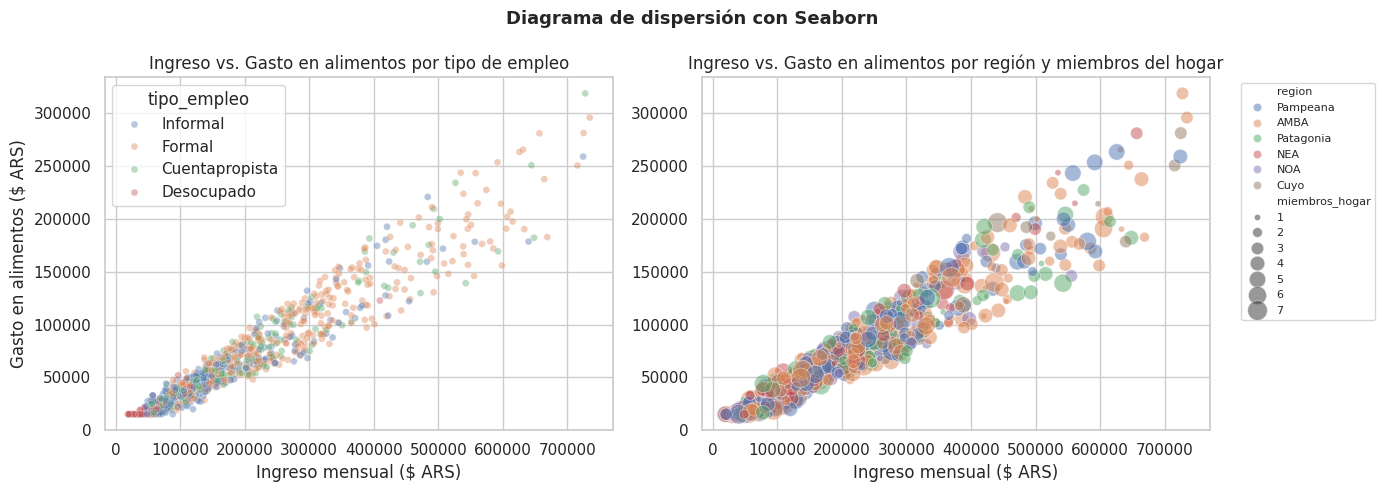

In [ ]:
# scatterplot con hue (color por categoría) y size (tamaño por variable numérica)
# alpha controla la transparencia de los puntos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: hue por tipo de empleo
sns.scatterplot(data=df_viz,
                x='ingreso_mensual',
                y='gasto_alimentos',
                hue='tipo_empleo',   # color por categoría
                alpha=0.4,
                s=25,                # tamaño fijo de los puntos
                ax=axes[0])
axes[0].set_title('Ingreso vs. Gasto en alimentos por tipo de empleo')
axes[0].set_xlabel('Ingreso mensual ($ ARS)')
axes[0].set_ylabel('Gasto en alimentos ($ ARS)')

# Panel derecho: hue por región, size por miembros del hogar
sns.scatterplot(data=df_viz,
                x='ingreso_mensual',
                y='gasto_alimentos',
                hue='region',        # color por región
                size='miembros_hogar', # tamaño por cantidad de miembros
                sizes=(20, 200),     # rango de tamaños
                alpha=0.5,
                ax=axes[1])
axes[1].set_title('Ingreso vs. Gasto en alimentos por región y miembros del hogar')
axes[1].set_xlabel('Ingreso mensual ($ ARS)')
axes[1].set_ylabel('')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('Diagrama de dispersión con Seaborn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** El panel derecho codifica tres variables en un solo gráfico: X (ingreso), Y (gasto), color (región) y tamaño (miembros del hogar). Esto permite detectar patrones multivariables — por ejemplo, si los hogares más grandes de Patagonia tienen ingresos sistemáticamente más altos. `bbox_to_anchor` mueve la leyenda fuera del gráfico para no tapar los puntos.

### 3.2 lineplot con hue

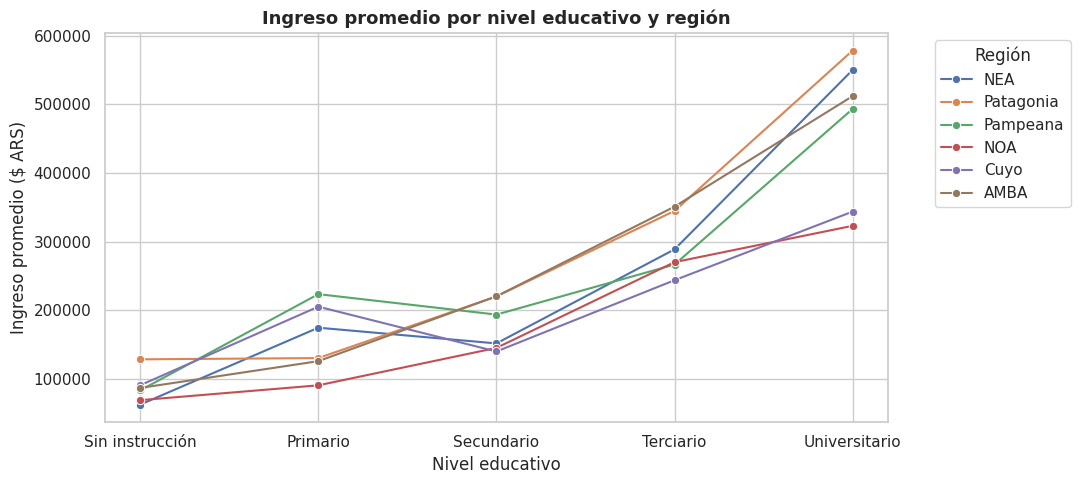

In [ ]:
# Calculamos el ingreso promedio por región y nivel educativo
ingreso_edu_region = (df.groupby(['nivel_educativo', 'region'])['ingreso_mensual']
                      .mean().reset_index())

# Orden lógico del nivel educativo
orden_edu = ['Sin instrucción', 'Primario', 'Secundario', 'Terciario', 'Universitario']
ingreso_edu_region['nivel_educativo'] = pd.Categorical(
    ingreso_edu_region['nivel_educativo'], categories=orden_edu, ordered=True)
ingreso_edu_region = ingreso_edu_region.sort_values('nivel_educativo')

fig, ax = plt.subplots(figsize=(11, 5))

# hue='region' dibuja una línea por región con color distinto
# marker='o' agrega puntos en cada valor
sns.lineplot(data=ingreso_edu_region,
             x='nivel_educativo',
             y='ingreso_mensual',
             hue='region',
             marker='o',
             ax=ax)

ax.set_title('Ingreso promedio por nivel educativo y región',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Ingreso promedio ($ ARS)')
ax.legend(title='Región', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación:** `lineplot` con `hue` dibuja una línea por cada categoría con un color distinto y genera la leyenda automáticamente. Se confirma que el ingreso crece con el nivel educativo en todas las regiones, pero Patagonia mantiene una ventaja consistente en todos los niveles. El cruce entre líneas revela que esa ventaja se amplía en los niveles más altos.

### 3.3 pairplot — matriz de relaciones

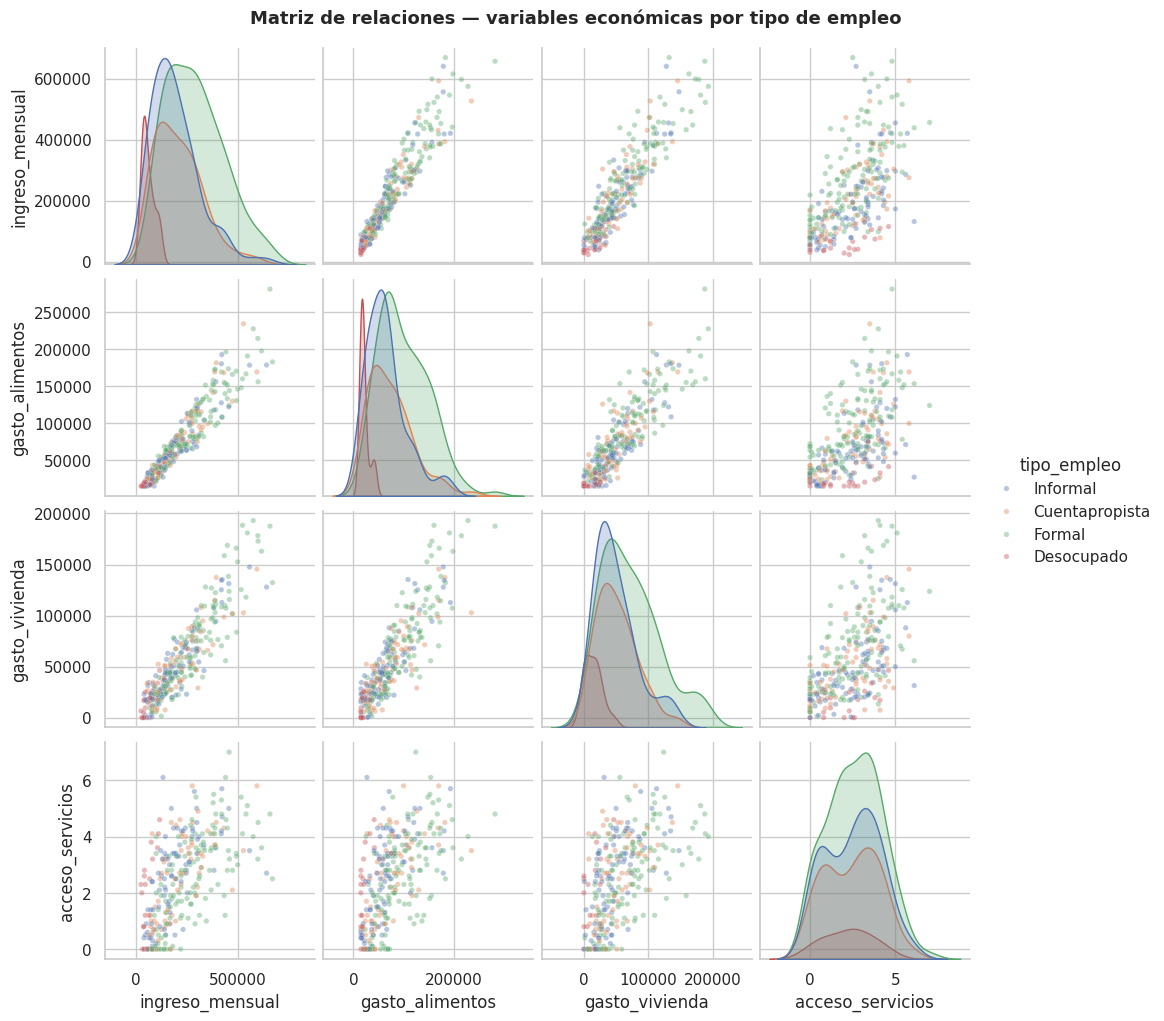

In [ ]:
# pairplot genera todos los scatterplots posibles entre variables numéricas
# hue diferencia los grupos por color
# La diagonal muestra la distribución de cada variable

vars_num = ['ingreso_mensual', 'gasto_alimentos', 'gasto_vivienda', 'acceso_servicios']

# Creamos un subset para que el pairplot no tarde demasiado
df_sample = df_viz[vars_num + ['tipo_empleo']].sample(300, random_state=42)

g = sns.pairplot(data=df_sample,
                 vars=vars_num,
                 hue='tipo_empleo',
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde',   # 'kde' o 'hist' en la diagonal
                 height=2.5)

g.figure.suptitle('Matriz de relaciones — variables económicas por tipo de empleo',
                  y=1.02, fontsize=13, fontweight='bold')
plt.show()

> **Interpretación:** El pairplot muestra en una sola figura todas las relaciones bivariadas entre las variables seleccionadas. La diagonal muestra la distribución de cada variable separada por tipo de empleo. Se confirman visualmente las correlaciones altas del heatmap — ingreso y gasto_alimentos forman una nube muy compacta. `diag_kind='kde'` es preferible a `'hist'` cuando hay múltiples grupos porque las curvas se superponen más limpiamente.

---

## — Variables categóricas: barplot y catplot

> **Síntesis teórica**
>
> **`sns.barplot`** — gráfico de barras con estimación estadística
> A diferencia de `plt.bar`, `sns.barplot` calcula automáticamente la media (o cualquier estimador) y el intervalo de confianza para cada categoría. Cuando hay múltiples observaciones por categoría, Seaborn agrega y calcula la estadística sin necesidad de hacerlo manualmente.
>
> Parámetros clave:
> - `estimator`: función de agregación (`"mean"`, `"median"`, `"sum"`, etc.).
> - `errorbar`: controla las barras de error (`None` para suprimirlas, `"sd"` para desvío estándar, `"ci"` para intervalo de confianza).
> - `hue`: agrega una segunda variable categórica con colores.
>
> **`sns.catplot`** — figura de nivel superior para gráficos categóricos
> Equivalente a `FacetGrid` pero especializado en variables categóricas. El parámetro `kind` selecciona el tipo de gráfico: `"box"`, `"violin"`, `"bar"`, `"strip"`, `"swarm"`, `"boxen"`, `"point"`.
>
> **¿Cuándo usar cada uno?**
> - `barplot`: para comparar una estadística resumen entre categorías.
> - `catplot` con `kind="box"` o `kind="violin"`: para comparar distribuciones completas entre categorías.

### 4.1 barplot — ingreso promedio por nivel educativo

/tmp/ipykernel_15602/710552344.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz,
/tmp/ipykernel_15602/710552344.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz,


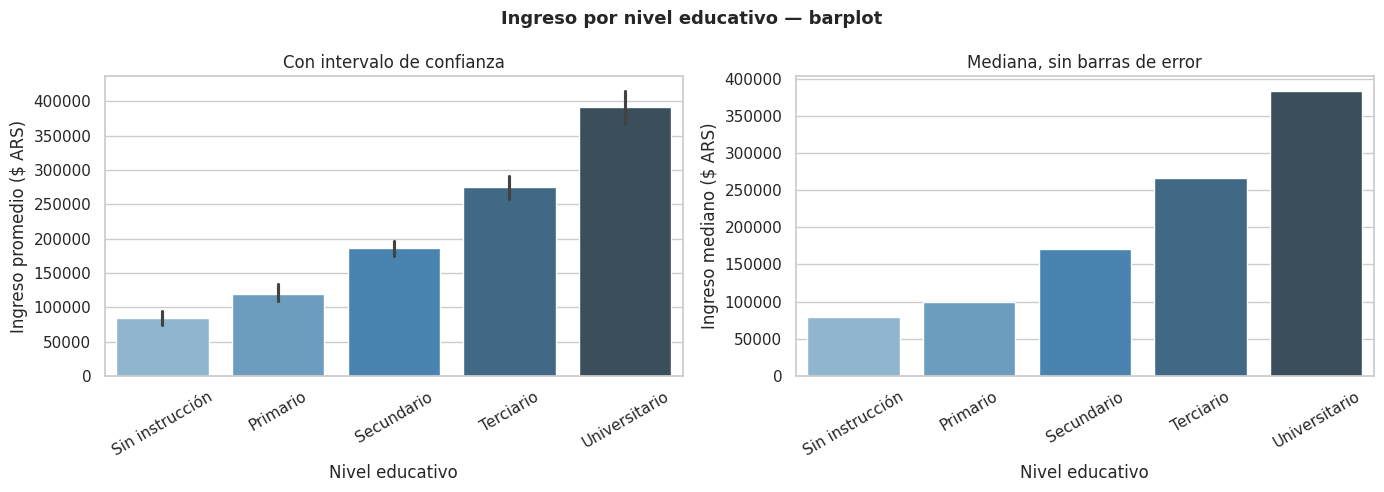

In [ ]:
# barplot calcula la media automáticamente para cada categoría
# errorbar=None suprime las barras de error para mayor claridad
# order controla el orden de las barras

orden_edu = ['Sin instrucción', 'Primario', 'Secundario', 'Terciario', 'Universitario']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: con intervalo de confianza (por defecto)
sns.barplot(data=df_viz,
            x='nivel_educativo',
            y='ingreso_mensual',
            order=orden_edu,
            estimator='mean',
            errorbar='ci',          # intervalo de confianza al 95%
            palette='Blues_d',
            ax=axes[0])
axes[0].set_title('Con intervalo de confianza')
axes[0].set_xlabel('Nivel educativo')
axes[0].set_ylabel('Ingreso promedio ($ ARS)')
axes[0].tick_params(axis='x', rotation=30)

# Panel derecho: sin barras de error, con mediana
sns.barplot(data=df_viz,
            x='nivel_educativo',
            y='ingreso_mensual',
            order=orden_edu,
            estimator='median',     # mediana en lugar de media
            errorbar=None,          # sin barras de error
            palette='Blues_d',
            ax=axes[1])
axes[1].set_title('Mediana, sin barras de error')
axes[1].set_xlabel('Nivel educativo')
axes[1].set_ylabel('Ingreso mediano ($ ARS)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Ingreso por nivel educativo — barplot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** El panel izquierdo muestra la media con intervalos de confianza — las líneas negras indican el rango dentro del cual cae la media verdadera con 95% de probabilidad. El panel derecho usa la mediana, que es más robusta ante outliers. Compará los valores: la media universitaria es más alta que la mediana universitaria, lo que confirma que hay outliers altos que tiran el promedio hacia arriba.

### 4.2 barplot con hue — comparación doble

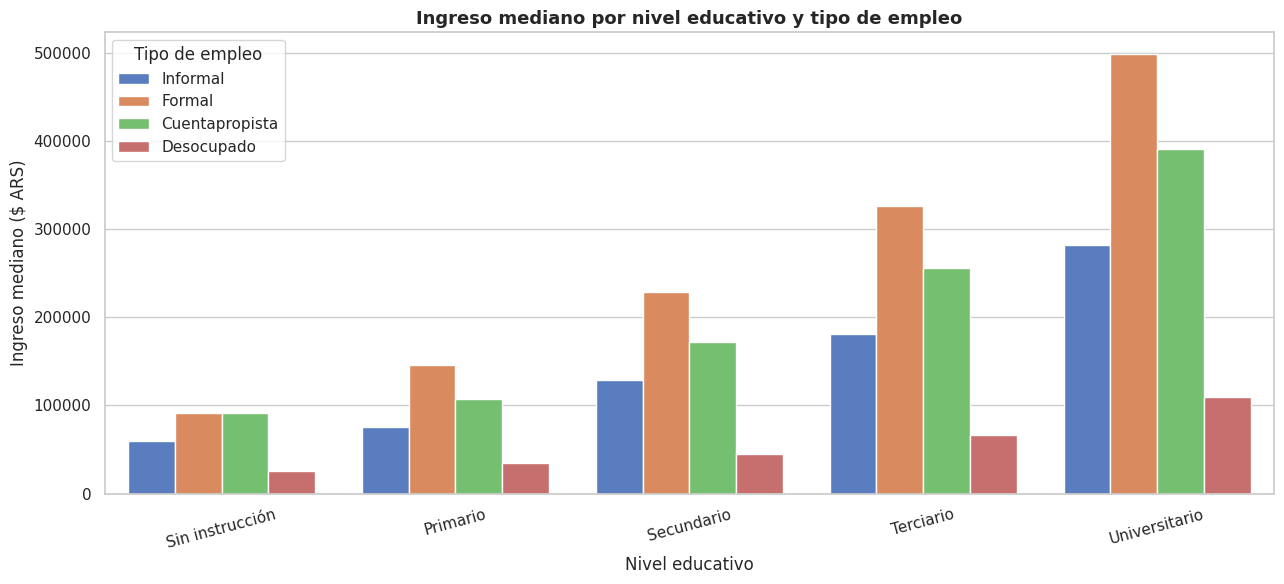

In [ ]:
# hue agrega una segunda variable categórica
# Cada grupo de barras muestra el ingreso por nivel educativo
# y dentro de cada grupo, separa por tipo de empleo

fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(data=df_viz,
            x='nivel_educativo',
            y='ingreso_mensual',
            hue='tipo_empleo',
            order=orden_edu,
            estimator='median',
            errorbar=None,
            palette='muted',
            ax=ax)

ax.set_title('Ingreso mediano por nivel educativo y tipo de empleo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Ingreso mediano ($ ARS)')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Tipo de empleo', loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación:** Con `hue` se reproducen las diferencias que vimos en el boxplot combinado de Matplotlib, pero en forma de barras de altura. Se confirma que en Universitario la diferencia entre Formal e Informal es la más dramática. Seaborn agrupa automáticamente las barras y ajusta el ancho para que quepan todas las categorías.

### 4.3 catplot — boxplot y violin plot

/tmp/ipykernel_15602/2845962237.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz,
/tmp/ipykernel_15602/2845962237.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz,


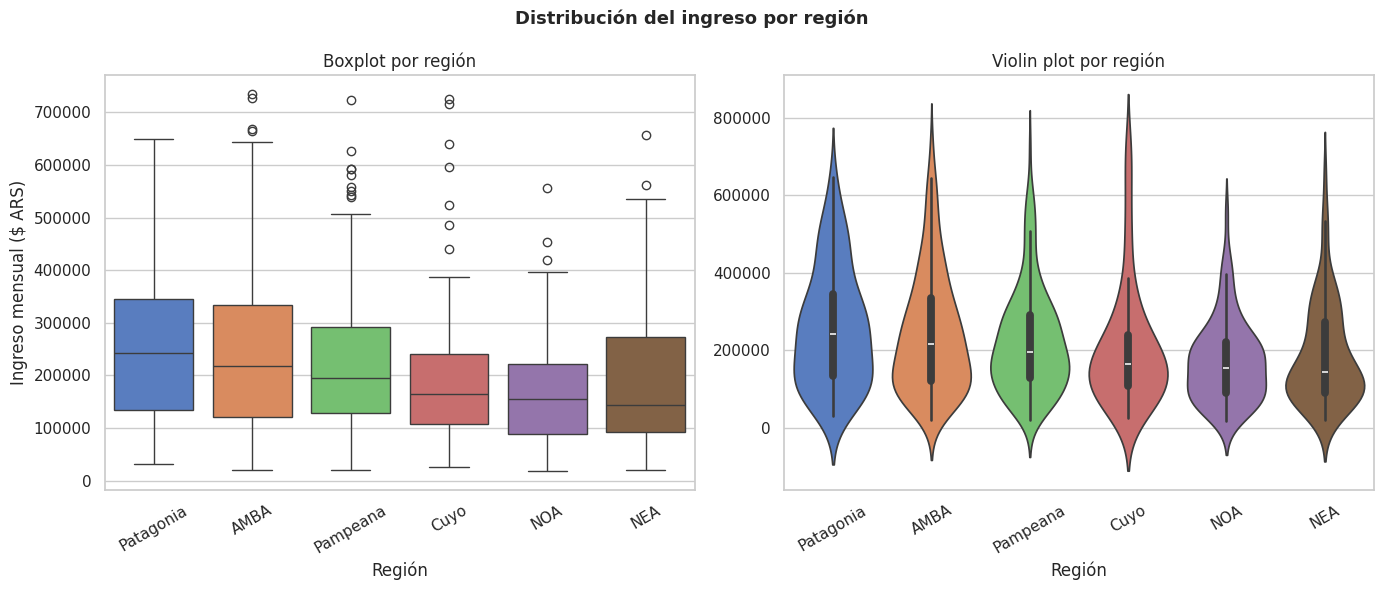

In [ ]:
# catplot es la función de nivel superior para gráficos categóricos
# kind='box' genera boxplots
# kind='violin' genera violin plots
# col o row divide la figura en facetas

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: boxplot
with sns.axes_style('whitegrid'):
    sns.boxplot(data=df_viz,
                x='region',
                y='ingreso_mensual',
                order=df_viz.groupby('region')['ingreso_mensual']
                            .median().sort_values(ascending=False).index,
                palette='muted',
                ax=axes[0])
axes[0].set_title('Boxplot por región')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Ingreso mensual ($ ARS)')
axes[0].tick_params(axis='x', rotation=30)

# Panel derecho: violin plot
with sns.axes_style('whitegrid'):
    sns.violinplot(data=df_viz,
                   x='region',
                   y='ingreso_mensual',
                   order=df_viz.groupby('region')['ingreso_mensual']
                               .median().sort_values(ascending=False).index,
                   palette='muted',
                   inner='box',   # muestra el boxplot dentro del violín
                   ax=axes[1])
axes[1].set_title('Violin plot por región')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Distribución del ingreso por región', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** `inner='box'` dentro del violin plot muestra el boxplot embebido — se puede ver simultáneamente la forma completa de la distribución (violín) y los cuartiles concretos (caja). Seaborn ordena las regiones por mediana automáticamente cuando se pasa el índice ordenado en `order`. Comparar los dos paneles muestra qué agrega el violín respecto al boxplot: la forma de la distribución en NOA y NEA confirma la concentración en valores bajos que vimos antes.

---

##  — Grillas avanzadas: FacetGrid y jointplot

> **Síntesis teórica**
>
> **`sns.FacetGrid`** — grilla de facetas
> Divide un DataFrame en subgráficos según los valores de una o más variables categóricas. Es la versión Seaborn de `plt.subplots` pero orientada a datos: en lugar de definir la grilla manualmente, Seaborn la genera automáticamente a partir de las categorías de los datos.
>
> Flujo de uso:
> 1. Crear la grilla: `g = sns.FacetGrid(data, col="variable", row="variable")`
> 2. Mapear una función de dibujo: `g.map(sns.histplot, "columna")`
> 3. (Opcional) Agregar leyenda: `g.add_legend()`
>
> **`sns.jointplot`** — distribución conjunta con marginales
> Muestra la relación entre dos variables numéricas (panel central) junto con sus distribuciones individuales (paneles marginales). El parámetro `kind` controla el tipo de gráfico central: `"scatter"`, `"kde"`, `"hist"`, `"hex"`, `"reg"`.
>
> **¿Cuándo usar cada uno?**
> - `FacetGrid`: cuando se quiere comparar el mismo análisis entre subgrupos definidos por una variable categórica.
> - `jointplot`: cuando se quiere ver simultáneamente la relación entre dos variables y sus distribuciones individuales.

### 5.1 FacetGrid — distribución del ingreso por región

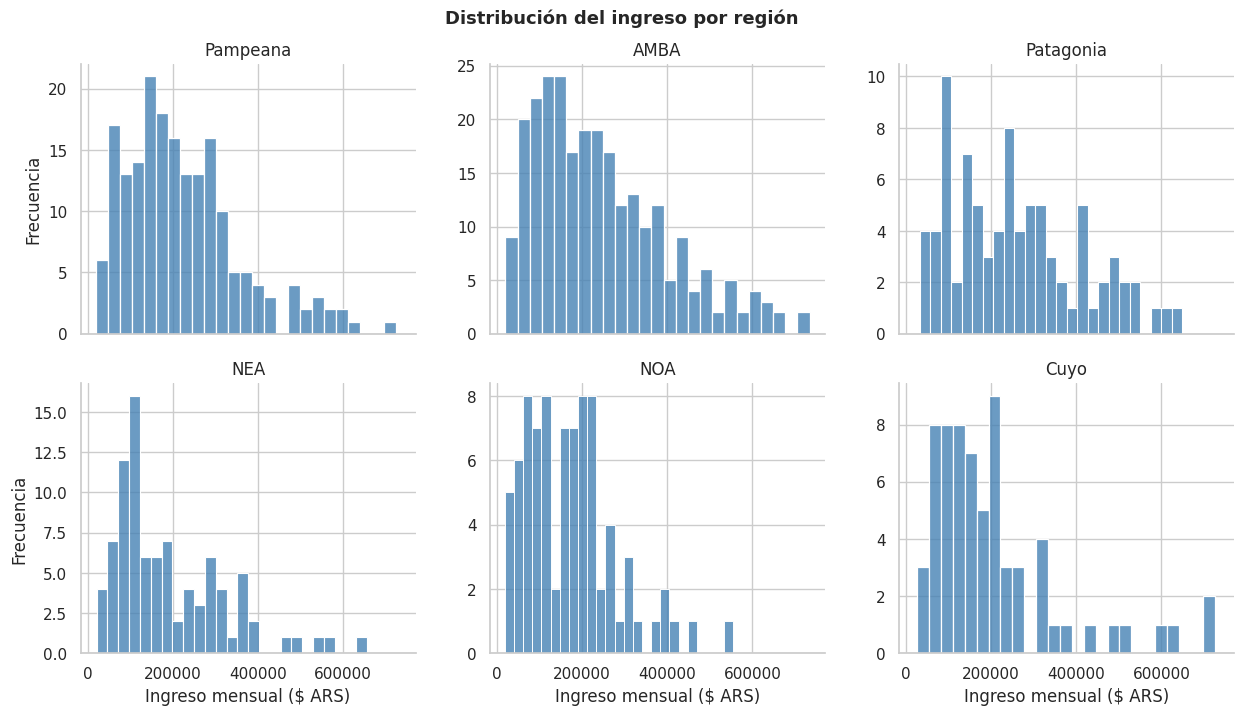

In [ ]:
# FacetGrid divide la figura en paneles según los valores de 'col'
# col_wrap controla cuántos paneles hay por fila

g = sns.FacetGrid(data=df_viz,
                  col='region',
                  col_wrap=3,         # máximo 3 columnas
                  height=3.5,
                  aspect=1.2,
                  sharey=False)       # cada panel tiene su propio eje Y

# map aplica la función de dibujo a cada panel
g.map(sns.histplot, 'ingreso_mensual',
      bins=25, color='steelblue', alpha=0.8)

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Ingreso mensual ($ ARS)', 'Frecuencia')
g.figure.suptitle('Distribución del ingreso por región',
                   y=1.02, fontsize=13, fontweight='bold')
plt.show()

> **Interpretación:** `FacetGrid` genera automáticamente un panel por cada región. `col_wrap=3` organiza los paneles en filas de tres. `sharey=False` permite que cada panel tenga su propio eje Y — útil cuando los grupos tienen tamaños muy distintos (AMBA tiene muchos más hogares que Patagonia). Se confirma que NOA y NEA tienen distribuciones más compactas y bajas que Patagonia y AMBA.

### 5.2 FacetGrid con map_dataframe

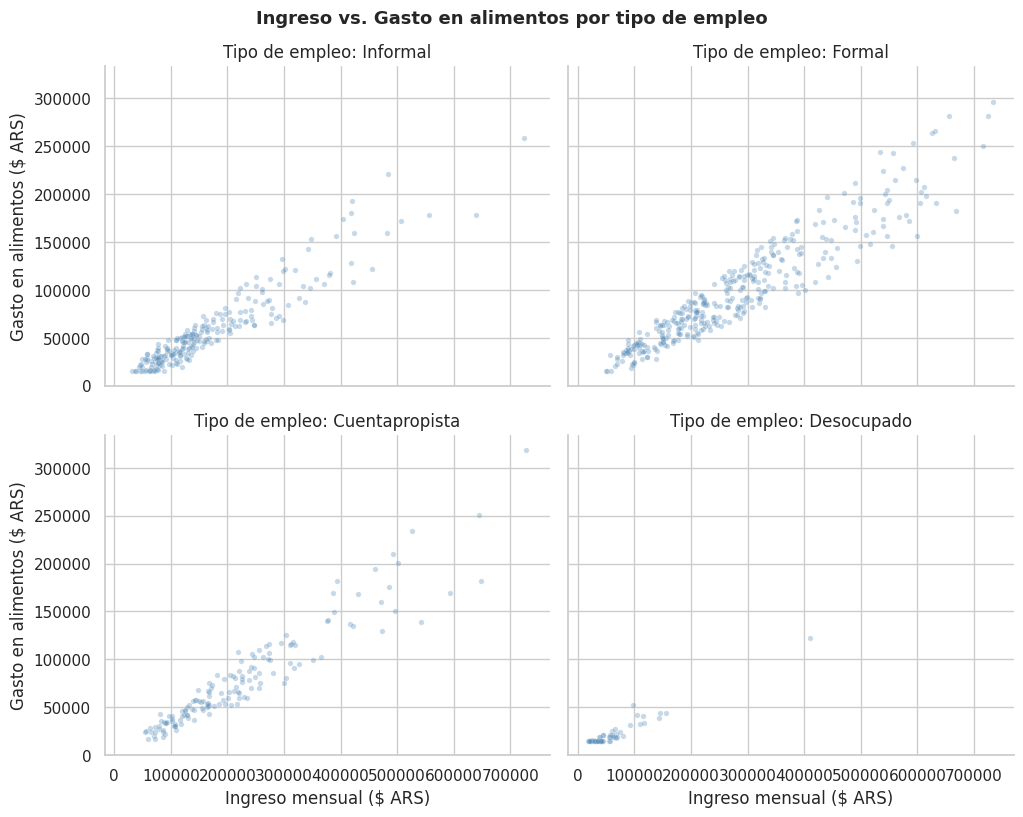

In [ ]:
# map_dataframe permite pasar argumentos con nombre a la función de dibujo
# Útil cuando la función requiere x= y= en lugar de argumentos posicionales

g = sns.FacetGrid(data=df_viz,
                  col='tipo_empleo',
                  col_wrap=2,
                  height=4,
                  aspect=1.3)

# map_dataframe pasa el DataFrame completo a cada panel
# y permite usar argumentos con nombre (x=, y=)
g.map_dataframe(sns.scatterplot,
                x='ingreso_mensual',
                y='gasto_alimentos',
                alpha=0.3,
                s=15,
                color='steelblue')

g.set_titles(col_template='Tipo de empleo: {col_name}')
g.set_axis_labels('Ingreso mensual ($ ARS)', 'Gasto en alimentos ($ ARS)')
g.figure.suptitle('Ingreso vs. Gasto en alimentos por tipo de empleo',
                   y=1.02, fontsize=13, fontweight='bold')
plt.show()

> **Interpretación:** `map_dataframe` es necesario cuando la función de dibujo usa argumentos con nombre (`x=`, `y=`) en lugar de argumentos posicionales. La grilla separa visualmente los cuatro tipos de empleo — se confirma que los Desocupados (abajo a la izquierda) están completamente separados del resto, y que los Formales tienen la nube más extendida hacia la derecha (ingresos más altos).

### 5.3 jointplot — distribución conjunta con marginales

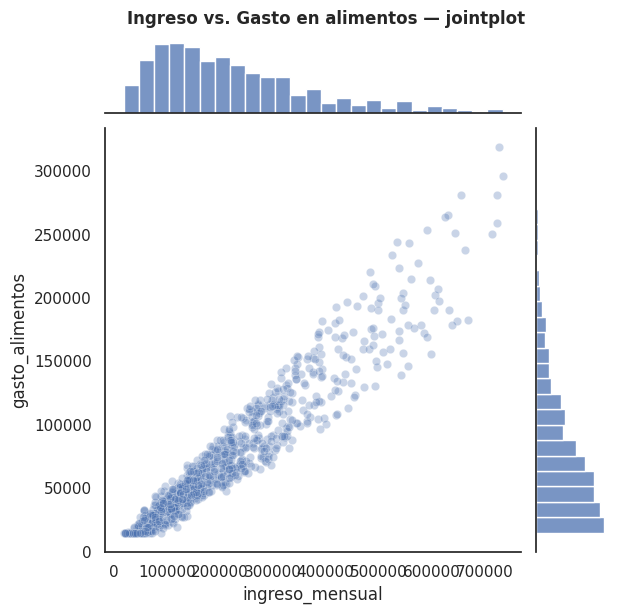

In [ ]:
# jointplot muestra el scatter central + histogramas marginales
# kind='scatter' es el más simple
# kind='hex' es mejor con muchos puntos

fig_kws = {'figsize': (7, 7)}

# kind='scatter' con regresión lineal
with sns.axes_style('white'):
    g = sns.jointplot(data=df_viz,
                      x='ingreso_mensual',
                      y='gasto_alimentos',
                      kind='scatter',
                      alpha=0.3,
                      marginal_kws={'bins': 25, 'fill': True})

g.figure.suptitle('Ingreso vs. Gasto en alimentos — jointplot',
                   y=1.02, fontsize=12, fontweight='bold')
plt.show()

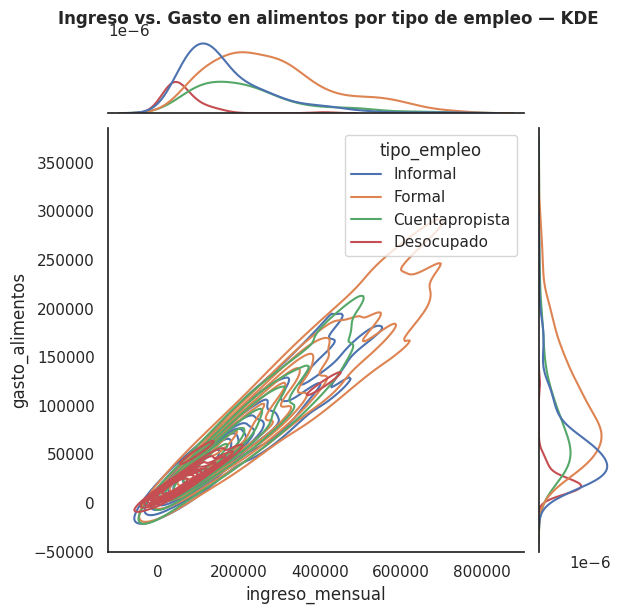

In [ ]:
# kind='kde' muestra contornos de densidad + KDE marginales
# hue separa los grupos con color

with sns.axes_style('white'):
    g = sns.jointplot(data=df_viz,
                      x='ingreso_mensual',
                      y='gasto_alimentos',
                      hue='tipo_empleo',
                      kind='kde',
                      fill=False)

g.figure.suptitle('Ingreso vs. Gasto en alimentos por tipo de empleo — KDE',
                   y=1.02, fontsize=12, fontweight='bold')
plt.show()

> **Interpretación:** El jointplot combina tres gráficos en uno: el scatter o KDE central muestra la relación entre las dos variables, y los histogramas o KDE en los márgenes muestran la distribución individual de cada variable. Con `hue`, el panel central con `kind='kde'` muestra contornos de densidad por tipo de empleo — se ven claramente separados los grupos Desocupado (concentrado abajo a la izquierda) del Formal (extendido hacia la derecha).

---

## Resumen: ¿qué función de Seaborn usar y cuándo?

| Función | Uso principal | Ventaja vs. Matplotlib |
|---|---|---|
| `sns.histplot` | Histograma de una variable | Integración con pandas, KDE incluido, múltiples grupos |
| `sns.kdeplot` | Curva de densidad suavizada | Comparación de distribuciones sin bins |
| `sns.scatterplot` | Dispersión entre dos numéricas | hue, size y style en un solo gráfico |
| `sns.lineplot` | Líneas con bandas de confianza | Calcula medias e intervalos automáticamente |
| `sns.pairplot` | Matriz de relaciones | Todas las relaciones bivariadas de una vez |
| `sns.barplot` | Barras con estadísticas | Media/mediana + intervalo de confianza automático |
| `sns.boxplot` | Distribución + outliers por grupo | Más integrado con pandas que plt.boxplot |
| `sns.violinplot` | Forma completa de distribución | Combina boxplot + densidad |
| `sns.FacetGrid` | Grilla por categorías | Genera paneles automáticamente desde los datos |
| `sns.jointplot` | Relación + distribuciones marginales | Tres gráficos en uno sin código adicional |